<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'> DECISION TREE RANDOM FOREST </h2>
</div>

### 1. Decision Tree		
		
   - Is a tree like structure in which internal node represents test on an attribute

   - Here input is not discrete or continous value, its categorial/Classification values and o/p is labelled or categorial, then we use Decision tree

   - DT is based on some conditions

### 2. Random Forest

   - Its a Ensemble Technique : 	
            Means many same type algorithm (DT) are used to build, so its called as ENSEMBLE Teqnique

   - Its combination of many Decision tree, every DT o/p will be considered and majority will be the final o/p	

   - Each DT uses different combination of conditions in each node and final o/p is decided.	

   - It’s a mutiple Dtand merged them together to get more accurate result	

   - RF alsways gives very good precision	

   - here n_estimators will be the no of DT in the model	

   - n_estimator:number of trees in the forest.	


    
### 3. Gradient Boosted Decison Trees (GBDT) :			
			
   - Its same as random forest, it ensembles samples of multiple trees to create powerful prediction for classification and regression problem.	
			
			
   - Learning Rate:		
		
   - This is one of the parameter in GBDT	

   - More learning rate, will build more complex model with high accuracy but becomes like overfit, Low learning rate will build simple model with little les accuracy.	


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


# Module 7–Supervised Learning -I

    Domain –Banking/Loan
    focus –Lower NPA (Non Performing Asset)
    
    usiness challenge/requirement
        PeerLoanKart is anNBFC (Non-BankingFinancial Company) which facilitates peer to peer loan. 
        It connects people who need money (borrowers) with people who have money (investors). 
        As an investor,you would want to invest in people who showed a profile of having a high probability of paying you back. 
        
        You as a ML expert create a model that will help predict whether a borrower will pay the loan or not. 

## Key issues
    Ensure NPAs are lower –> meaning PeerLoanKart wants to be very diligent in giving loans to borrower
    NPA - Non-performing asset
    
    Business benefits:
        Increase in profits up to 20% as NPA will be reduced due to loan disbursal for only good borrowers


# Module 7: Loan Eligibility Case Study

Here are what the data represent:
* credit.policy: 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
* purpose: The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
* int.rate: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
* installment: The monthly installments owed by the borrower if the loan is funded.
* log.annual.inc: The natural log of the self-reported annual income of the borrower.
* dti: The debt-to-income ratio of the borrower (amount of debt divided by annual income).
* fico: The FICO credit score of the borrower.
* days.with.cr.line: The number of days the borrower has had a credit line.
* revol.bal: The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).
* revol.util: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
* inq.last.6mths: The borrower's number of inquiries by creditors in the last 6 months.
* delinq.2yrs: The number of times the borrower had been 30+ days past due on a payment in the past 2 years.
* pub.rec: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

** not.fully.paid: This is the output field. Please note that 1 means borrower is not going to pay the loan completely** 

#### Start analyze
* By seeing data " not.fully.paid" is the target it has 0 or 1, 1 means not going to pay.
* we have data as binary o/p, but we disnt use logistic regression, we used DT and RF. 
* we build the model, based on all i/p we can decide, weather he will pay or not


    * But not sure how to tell, based on which i/p field we can tell the bank weather he is good borrower or not before giving???

#### TYPE OF PROBLEM:
 > The above problem is a clear classification problem as we need to classify whether the Loan_Status is yes or no. So this can be solved by any of the classification techniques like

    > Logistic Regression .

    > Decision Tree Algorithm.

    > Random Forest Technique.

##  1. Import all Librariy

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

loans = pd.read_csv(r"..\Dataset\loan_borowwer_data.csv")
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
credit.policy        9578 non-null int64
purpose              9578 non-null object
int.rate             9578 non-null float64
installment          9578 non-null float64
log.annual.inc       9578 non-null float64
dti                  9578 non-null float64
fico                 9578 non-null int64
days.with.cr.line    9578 non-null float64
revol.bal            9578 non-null int64
revol.util           9578 non-null float64
inq.last.6mths       9578 non-null int64
delinq.2yrs          9578 non-null int64
pub.rec              9578 non-null int64
not.fully.paid       9578 non-null int64
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


* no null values, data looks ok

In [2]:
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## 2. Data Exploration with Graphs and Visualization

    Let's do some data visualization!
** Create a histogram of two FICO distributions on top of each other, one for each credit.policy outcome.**

Text(0.5, 0, 'FICO')

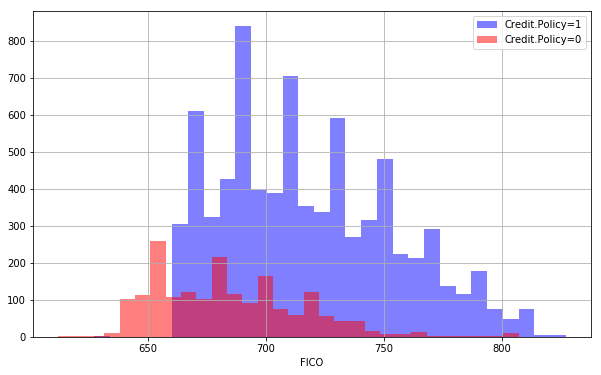

In [2]:
plt.figure(figsize=(10,6))
loans[loans['credit.policy']==1]['fico'].hist(alpha=0.5,color='blue',
                                              bins=30,label='Credit.Policy=1')
loans[loans['credit.policy']==0]['fico'].hist(alpha=0.5,color='red',
                                              bins=30,label='Credit.Policy=0')
plt.legend()
plt.xlabel('FICO')

** credit.policy: 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
** fico: The FICO credit score of the borrower.
    
    * By this we can see max customer who met the credit underwriting criteri i.e credit.policy = 1, corresponding 
        Fico(credit score of the borrower.) histogram/freq distribution provided, 
        max freq are there where Rating 650 to 700 related bins
    


** Create a similar figure, except this time select by the not.fully.paid column.**

Text(0.5, 0, 'FICO')

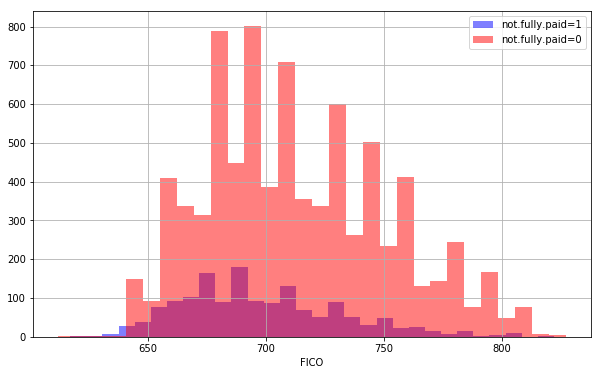

In [3]:
plt.figure(figsize=(10,6))
loans[loans['not.fully.paid']==1]['fico'].hist(alpha=0.5,color='blue',
                                              bins=30,label='not.fully.paid=1')
loans[loans['not.fully.paid']==0]['fico'].hist(alpha=0.5,color='red',
                                              bins=30,label='not.fully.paid=0')
plt.legend()
plt.xlabel('FICO')

*  not.fully.paid: This is the output field. Please note that 1 means borrower is not going to pay the loan completely** 
    *  Looks like all credit score range people are there in not fully paid stack/bar
    * Credit scores are more, there less no of not fully paid(1) customer 
    * Credit scores 650 t0 700 related bins are having more  not fully paid customer 

** Create a countplot using seaborn showing the counts of loans by purpose, with the color hue defined by not.fully.paid. **

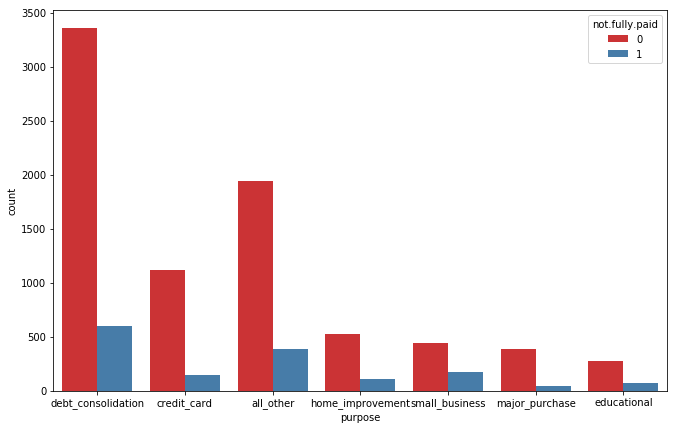

In [4]:
import seaborn as sns
plt.figure(figsize=(11,7))
sns.countplot(x='purpose',hue='not.fully.paid',data=loans,palette='Set1')

*  not.fully.paid: This is the output field. Please note that 1 means borrower is not going to pay the loan completely** 
    * Looks like in all purpose category fully not paid custmer(1) are there
    * In that dept_consolidator has more count of not fully paid customer

                   credit.policy  int.rate  installment  log.annual.inc  \
credit.policy           1.000000 -0.294089     0.058770        0.034906   
int.rate               -0.294089  1.000000     0.276140        0.056383   
installment             0.058770  0.276140     1.000000        0.448102   
log.annual.inc          0.034906  0.056383     0.448102        1.000000   
dti                    -0.090901  0.220006     0.050202       -0.054065   
fico                    0.348319 -0.714821     0.086039        0.114576   
days.with.cr.line       0.099026 -0.124022     0.183297        0.336896   
revol.bal              -0.187518  0.092527     0.233625        0.372140   
revol.util             -0.104095  0.464837     0.081356        0.054881   
inq.last.6mths         -0.535511  0.202780    -0.010419        0.029171   
delinq.2yrs            -0.076318  0.156079    -0.004368        0.029203   
pub.rec                -0.054243  0.098162    -0.032760        0.016506   
not.fully.paid         -0

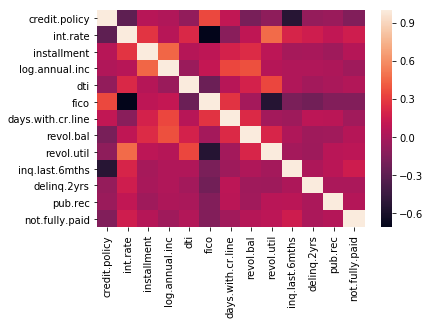

In [5]:
# With Heat map also we can decide which are correlated more and we can ignore repeatative type

corr = loans.corr()
print(corr)
#plt.figure(figsize=(5,10))
sns.heatmap(corr)
plt.show()

## Setting up the Data
    Let's get ready to set up our data for our  Classification Model!

**Check loans.info() again.**

In [6]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
credit.policy        9578 non-null int64
purpose              9578 non-null object
int.rate             9578 non-null float64
installment          9578 non-null float64
log.annual.inc       9578 non-null float64
dti                  9578 non-null float64
fico                 9578 non-null int64
days.with.cr.line    9578 non-null float64
revol.bal            9578 non-null int64
revol.util           9578 non-null float64
inq.last.6mths       9578 non-null int64
delinq.2yrs          9578 non-null int64
pub.rec              9578 non-null int64
not.fully.paid       9578 non-null int64
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


## Categorical Features

Notice that the **purpose** column as categorical

That means we need to transform them using dummy variables so sklearn will be able to understand them. Let's do this in one clean step using pd.get_dummies.(One_hot_dog encoding)

Let's show you a way of dealing with these columns that can be expanded to multiple categorical features if necessary.

**Create a list of 1 element containing the string 'purpose'. Call this list cat_feats.**

In [6]:
cat_feats = ['purpose']

**Now use pd.get_dummies(loans,columns=cat_feats,drop_first=True) to create a fixed larger dataframe that has new feature columns with dummy variables. Set this dataframe as final_data.**

In [8]:
# Here we convert column 'purpose' value as each new column which is One_hot_dog encoding
final_data = pd.get_dummies(loans,columns=cat_feats,drop_first=True)

In [9]:
final_data.info()
#Here after one-hot , it increased col number baed on distinct purpose values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 19 columns):
credit.policy                 9578 non-null int64
int.rate                      9578 non-null float64
installment                   9578 non-null float64
log.annual.inc                9578 non-null float64
dti                           9578 non-null float64
fico                          9578 non-null int64
days.with.cr.line             9578 non-null float64
revol.bal                     9578 non-null int64
revol.util                    9578 non-null float64
inq.last.6mths                9578 non-null int64
delinq.2yrs                   9578 non-null int64
pub.rec                       9578 non-null int64
not.fully.paid                9578 non-null int64
purpose_credit_card           9578 non-null uint8
purpose_debt_consolidation    9578 non-null uint8
purpose_educational           9578 non-null uint8
purpose_home_improvement      9578 non-null uint8
purpose_major_purchase        9


* Each of the feild purpose_ will have value 0 or 1 based on the category **

## Train Test Split

Now its time to split our data into a training set and a testing set!

** Use sklearn to split your data into a training set and a testing set as we've done in the past.**

# Drop the not.fully.paid column as it is the output column and Not A Feature
X = final_data.drop('not.fully.paid',axis=1)
y = final_data['not.fully.paid']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)
# Remember the significance of random_state value

In [10]:
from sklearn.model_selection import train_test_split
X = final_data.drop('not.fully.paid',axis=1)
y = final_data['not.fully.paid']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

# 3.1 Building Machine Learning Logistic Models

In [15]:
from sklearn.linear_model import LogisticRegression
# let's train the model
log_reg = LogisticRegression()

log_reg.fit(X_train,y_train)

# test the model
predictions_logR = log_reg.predict(X_test)


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)



# 3.2 Building Machine Learning Decision Tree Models

#### Training a Decision Tree Model

Let's start by training a single decision tree first!

** Import DecisionTreeClassifier**

In [16]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)
predictions_Dt = dtree.predict(X_test)

# 3.3 Building Machine Learning Random Foest Models

### Training the Random Forest model

Now its time to train our model!

**Create an instance of the RandomForestClassifier class and fit it to our training data from the previous step.**

In [17]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=600)
rfc.fit(X_train,y_train)
predictions_rf = rfc.predict(X_test)

# 3.4 Building Machine Learning With GRID SEARCH CV

In [32]:
# Using GridSearchCV in Logistic regression
from sklearn.model_selection import GridSearchCV

param_grid = {'penalty' : ['l2','l1'],
            'C' : [0.001, 0.01, 0.1, 1, 10, 100, 1000]
             }
#Assign Logistic regression without parameter
log_clf = LogisticRegression(random_state = 42)
#Here scoring is 'accuracy' we can try another similar grid search wth scoring as 'recall'
CV_log_clf = GridSearchCV(estimator = log_clf, param_grid = param_grid , scoring = 'accuracy', verbose = 1, n_jobs = -1)
CV_log_clf.fit(X_train,y_train)
best_parameters = CV_log_clf.best_params_
print(best_parameters)

random_state = 42
# Fit the logistic regression with best parameter
log_clf = LogisticRegression(C = best_parameters['C'], penalty = best_parameters['penalty'],random_state = random_state)

log_clf.fit(X_train,y_train)
#Y_pred
y_pred = log_clf.predict(X_test)



C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Fitting 3 folds for each of 14 candidates, totalling 42 fits
{'C': 0.001, 'penalty': 'l1'}


[Parallel(n_jobs=-1)]: Done  42 out of  42 | elapsed:    5.6s finished
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


# 4. Model Evaluation

## 4.1. Model Evaluation -Accuracy Score

In [33]:
print("Logistic Regression Accuracy :" ,metrics.accuracy_score(y_test, predictions_logR))
print("Decision Tree Accuracy :" ,metrics.accuracy_score(y_test, predictions_Dt))
print("Random Forest Accuracy :" ,metrics.accuracy_score(y_test, predictions_rf))
print("Grid search CV Log Reg :" ,metrics.accuracy_score(y_test, y_pred))

Logistic Regression Accuracy : 0.8458594293667363
Decision Tree Accuracy : 0.7306889352818372
Random Forest Accuracy : 0.8465553235908142
Grid search CV Log Reg : 0.8455114822546973


> Accuracy wise Logistic and Random forest and Grid search CV are having best value

## 4.2. Model Evaluation - confusion_matrix  

In [34]:
# confusion_matrix
print("Logistic Regression confusion_matrix :" ,confusion_matrix(y_test, predictions_logR))
print("Decision Tree confusion_matrix :" ,confusion_matrix(y_test, predictions_Dt))
print("Random Forest confusion_matrix :" ,confusion_matrix(y_test, predictions_rf))
print("Grid search CV Log Reg :" ,metrics.confusion_matrix(y_test, y_pred))


Logistic Regression confusion_matrix : [[2426    5]
 [ 438    5]]
Decision Tree confusion_matrix : [[1995  436]
 [ 338  105]]
Random Forest confusion_matrix : [[2423    8]
 [ 433   10]]
Grid search CV Log Reg : [[2430    1]
 [ 443    0]]


> Random Forest looks good

## 4.3. Model Evaluation - classification_report  

In [35]:
# classification_report

# Here we need to give categorial value instead of label encoded value. It will be easy to interpretate
print("Logistic Regression classification_report :" ,classification_report(y_test, predictions_logR))
print("Decision Tree classification_report :" ,classification_report(y_test, predictions_Dt))
print("Random Forest classification_report :" ,classification_report(y_test, predictions_rf))
print("Grid search CV Log Reg :" ,metrics.classification_report(y_test, y_pred))

Logistic Regression classification_report :               precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.50      0.01      0.02       443

   micro avg       0.85      0.85      0.85      2874
   macro avg       0.67      0.50      0.47      2874
weighted avg       0.79      0.85      0.78      2874

Decision Tree classification_report :               precision    recall  f1-score   support

           0       0.86      0.82      0.84      2431
           1       0.19      0.24      0.21       443

   micro avg       0.73      0.73      0.73      2874
   macro avg       0.52      0.53      0.53      2874
weighted avg       0.75      0.73      0.74      2874

Random Forest classification_report :               precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.56      0.02      0.04       443

   micro avg       0.85      0.85      0.85      2874
   macro

> Random Forest looks good

** Q1. Which model has a better avg. precision score ( Refer to score from Random Forest Also) ?  --> Random Forest
<br>Q2. Which model has a better recall score for prediction value 0 ( Refer to score from Random Forest Also) ?**


## 4.4. Model Evaluation - ROC AUC  

[0.13099549 0.23011262 0.06466747 0.15612208 0.2451868 ]
[0. 1. 0. 0. 0.]
[0.09666667 0.35666667 0.03       0.245      0.31833333]
[0.16152768 0.26788244 0.0891912  0.14435079 0.22752333]
Area under curve 0.6349735777434622
Area under curve 0.5288351271620426
Area under curve 0.6499819394521293
Area under curve 0.5860475999899716


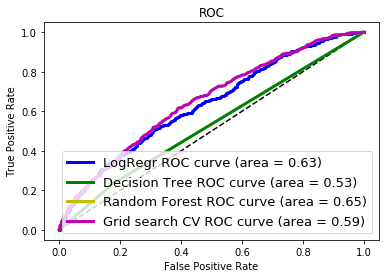

In [36]:
#ROC Curve with AUC
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

#Predictor_score LOG REG
y_pred_prob_LogR = log_reg.predict_proba(X_test)[:,1]
print(y_pred_prob_LogR[0:5])

#Predictor_score DT
y_pred_prob_dt = dtree.predict_proba(X_test)[:,1]
print(y_pred_prob_dt[0:5])

#Predictor_score RF
y_pred_prob_rf = rfc.predict_proba(X_test)[:,1]
print(y_pred_prob_rf[0:5])


#Predictor_score Grid serch CV
y_pred_prob = log_clf.predict_proba(X_test)[:,1]
print(y_pred_prob[0:5])



# ROC curve Log Reg
fpr_LogR, tpr_LogR, thresholds_LogR = roc_curve(y_test, y_pred_prob_LogR)

roc_auc_logR = auc(fpr_LogR, tpr_LogR)
print("Area under curve %s" %roc_auc_logR)

# ROC curve DT
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_prob_dt)

roc_auc_dt = auc(fpr_dt, tpr_dt)
print("Area under curve %s" %roc_auc_dt)

# ROC curve RF
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_prob_rf)

roc_auc_rf = auc(fpr_rf, tpr_rf)
print("Area under curve %s" %roc_auc_rf)


# ROC curve Grid search CV
fpr_CV, tpr_CV, thresholds_CV = roc_curve(y_test, y_pred_prob)

roc_auc_CV = auc(fpr_CV, tpr_CV)
print("Area under curve %s" %roc_auc_CV)




# Plot ROC Diagnol curve
plt.plot([0, 1], [0, 1], 'k--')

#plt.plot(fpr, tpr)  # X axis false +ve rate, Y axis True +ve rate

# Or with AUC
plt.plot(fpr_LogR, tpr_LogR, color = 'b', lw=3, label='LogRegr ROC curve (area = {:0.2f})'.format(roc_auc_logR))
plt.plot(fpr_dt, tpr_dt, color = 'g', lw=3, label='Decision Tree ROC curve (area = {:0.2f})'.format(roc_auc_dt))
plt.plot(fpr_rf, tpr_rf, color = 'y', lw=3, label='Random Forest ROC curve (area = {:0.2f})'.format(roc_auc_rf))
plt.plot(fpr_rf, tpr_rf, color = 'M', lw=3, label='Grid search CV ROC curve (area = {:0.2f})'.format(roc_auc_CV))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=13)
plt.title('ROC')
plt.show()
## Compared to Prev method  this Grid seach approach has little less AUC

# 5. CONCLUSION
## ** Q3. What performed better the random forest or the decision tree for lower NPAs ? **

Conclusion Random forest is better precision and good confusion metrix